# 16c · GSE232381 · bulk_RNA_seq · why does the paper not reproduce?

Reads the series matrix and NCBI counts (notebook 10), `metadata.rds` (notebook 11) and notebook 16b's
comparison genes. Downloads the authors' own processed file from GEO and the SRA run table. Writes nothing.

**Question.** Are the public data the data of the paper (Chen YC et al. *Heliyon* 2024;10:e32303), and if
they are, why do the paper's Table 3 results not reproduce (notebook 16b)?

**Checks, each stated with its test:**
1. **Inventory.** The GEO samples against the columns of NCBI's counts table: which are missing, and what
   the SRA run table says about them (reads, bases, layout).
2. **The authors' processed file** on GEO: what it contains, and whether its numbers match Table 3.
3. **Sequencing batch.** GEO sample descriptions carry the sequencing flowcell. Flowcell against activity:
   cross-table and Fisher's exact test. If they are confounded, activity differences may be batch.

**Personal information in the public files.** In GEO, three of the 25 sample descriptions
(`!Sample_description` in the series matrix) begin with what appear to be personal names instead of
numeric sample codes. The authors' processed file uses the same labels in its column headers
("Expected count (…)", "TPM (…)", "FPKM (…)"). This notebook handles them as follows:
- a description is never printed; only its flowcell and lane are extracted and shown;
- the processed file's column labels are replaced by GSM identifiers as soon as the file is read, and its
  original headers are never printed;
- the downloaded files stay in `data/GSE232381/`, which is not committed.

These labels may be personal identifiers in a public record. GEO should be told, so the submitters can
replace them.

In [1]:
source("../src/paths.R")
suppressMessages({library(GEOquery); library(readxl)})
meta <- readRDS(art("GSE232381", "metadata.rds"))
gse  <- getGEO(filename = raw("GSE232381", "GSE232381_series_matrix.txt.gz"), getGPL = FALSE)
pd   <- pData(gse)
cnt  <- read.delim(raw("GSE232381", "GSE232381_raw_counts_GRCh38.p13_NCBI.tsv.gz"), check.names = FALSE, nrows = 2)
geo  <- data.frame(sample = pd$geo_accession,
                   activity = sub("treatment: ", "", pd$characteristics_ch1.1),
                   flowcell = sub("^.*_(H[A-Z0-9]{8})_L[0-9]$", "\\1", pd$description),
                   lane = sub("^.*_(L[0-9])$", "\\1", pd$description),
                   in_ncbi_counts = pd$geo_accession %in% colnames(cnt),
                   srx = sub("^.*term=", "", pd$relation.1), row.names = NULL)
geo$flowcell[!grepl("^H[A-Z0-9]{8}$", geo$flowcell)] <- NA
table(activity = geo$activity, in_ncbi_counts = geo$in_ncbi_counts)

             in_ncbi_counts
activity      FALSE TRUE
  active LN       2   10
  inactive LN     7    6

**SRA run table** for the BioProject (PRJNA971890).

In [2]:
f <- raw("GSE232381", "PRJNA971890_runinfo.csv")
if (!file.exists(f)) download.file("https://trace.ncbi.nlm.nih.gov/Traces/sra-db-be/runinfo?acc=PRJNA971890", f, quiet = TRUE)
ri <- read.csv(f)
ri <- ri[, intersect(c("Run", "Experiment", "spots", "bases", "avgLength", "LibraryLayout", "size_MB", "ReleaseDate"), names(ri))]
inv <- merge(geo[, c("sample", "activity", "in_ncbi_counts", "srx", "flowcell", "lane")], ri, by.x = "srx", by.y = "Experiment", all.x = TRUE)
inv[order(inv$in_ncbi_counts, inv$activity), setdiff(names(inv), "srx")]

,sample,activity,in_ncbi_counts,flowcell,lane,Run,spots,bases,avgLength,LibraryLayout,size_MB,ReleaseDate
,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<int>,<chr>
2,GSM7329681,active LN,FALSE,HV7GTDSX3,L2,SRR24520304,33986300,9695473831,285,PAIRED,3032,2024-06-14 12:31:48
11,GSM7329690,active LN,FALSE,HVJKGDSX3,L3,SRR24520295,32236666,9201514921,285,PAIRED,2858,2024-06-14 12:31:47
13,GSM7329692,inactive LN,FALSE,HV7GTDSX3,L2,SRR24520293,33010426,9425581090,285,PAIRED,2896,2024-06-14 12:31:48
14,GSM7329693,inactive LN,FALSE,HV7GTDSX3,L2,SRR24520292,23213106,6568147921,282,PAIRED,2037,2024-06-14 12:31:48
15,GSM7329694,inactive LN,FALSE,HFY3FDSX3,L4,SRR24520291,38808906,10866710910,280,PAIRED,3362,2024-06-14 12:31:48
16,GSM7329695,inactive LN,FALSE,HFY3FDSX3,L4,SRR24520290,30936271,8746279450,282,PAIRED,2706,2024-06-14 12:31:48
21,GSM7329700,inactive LN,FALSE,HFY3FDSX3,L4,SRR24520285,33802977,9535127409,282,PAIRED,2931,2024-06-14 12:31:48
24,GSM7329703,inactive LN,FALSE,H3NHJDSX3,L3,SRR24520282,30100560,8258745121,274,PAIRED,2566,2024-06-14 12:31:48
25,GSM7329704,inactive LN,FALSE,H3NHJDSX3,L3,SRR24520281,28746583,7876168897,273,PAIRED,2423,2024-06-14 12:31:48


**Result.** GEO has 25 samples: 12 active, 13 inactive. NCBI's counts table has 16 of them: 10 active,
6 inactive. The 9 it leaves out (2 active, 7 inactive) are in SRA as paired-end runs of the same kind
and size as the others (23 to 39 million read pairs). The run table gives no reason for leaving them out.

**The authors' processed file** (GEO series supplementary file). Its sample columns are labelled with the
first part of each GEO sample description; they are matched to GSM identifiers here, and only GSM
identifiers are shown.

In [3]:
f <- raw("GSE232381", "GSE232381_Processed_data_files-Active_LN_vs_Inactive_LN.xlsx")
if (!file.exists(f)) download.file("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE232nnn/GSE232381/suppl/GSE232381_Processed_data_files-Active_LN_vs_Inactive_LN.xlsx", f, mode = "wb", quiet = TRUE)
x <- as.data.frame(read_excel(f, sheet = 1))
label <- sub("^(PAXgene-test-)?([^_]+)_.*$", "\\2", pd$description)     # the label the file uses
gsm_of <- setNames(pd$geo_accession, label)
kind <- sub(" \\(.*$", "", names(x)); code <- sub("^.*\\((.*)\\)$", "\\1", names(x))
per_sample <- kind %in% c("Expected count", "TPM", "FPKM")
names(x)[per_sample] <- paste0(kind[per_sample], ":", gsm_of[code[per_sample]])
c(rows = nrow(x), sample_columns_per_measure = sum(kind == "Expected count"),
  matched_to_GSM = sum(!is.na(gsm_of[code[kind == "Expected count"]])))
table(unique(kind))
head(x[, c("GeneID", "Fold change (active_inactive)", "PPEE (active_inactive)", "Description")], 3)

rows sample_columns_per_measure 
                     26506                         25 
            matched_to_GSM 
                        25


   Description      EC Number Expected count    Fold change           FPKM 
             1              1              1              1              1 
        GeneID             GO        Pathway           PPEE            TPM 
             1              1              1              1              1 

,GeneID,Fold change (active_inactive),PPEE (active_inactive),Description
,<chr>,<chr>,<chr>,<chr>
1,A1BG,0.566012649755827,0.9619048902737239,alpha-1-B glycoprotein
2,A1BG-AS1,0.6453763216338431,0.9864466399756032,A1BG antisense RNA 1
3,A1CF,0.6582029526565639,0.999999999999998,APOBEC1 complementation factor


**Result.** The file covers all 25 samples, and every sample column matches a GSM identifier.

**What the file is.** Per-sample "Expected count", TPM and FPKM for all 25 GEO samples, then one
"Fold change" and one "PPEE" column for active against inactive. "Expected count" is the name RSEM gives
its counts (Li B, Dewey CN. *BMC Bioinformatics* 2011;12:323), and PPEE, the posterior probability of
equal expression, is the output of EBSeq (Leng N et al. *Bioinformatics* 2013;29:1035–1043). The file
therefore looks like an EBSeq comparison, not the DESeq2 or edgeR comparison the paper's Methods name.

**Test 2a. Same samples?** For each of the 16 samples in NCBI's counts table: Spearman correlation of
NCBI's counts with the authors' expected counts, over genes in both. A value near 1 means the same library.

In [4]:
nc <- read.delim(raw("GSE232381", "GSE232381_raw_counts_GRCh38.p13_NCBI.tsv.gz"), check.names = FALSE)
gi <- read.delim(file.path(NCBI, "Homo_sapiens.gene_info.gz"), quote = "", colClasses = "character")
nc_sym <- gi$Symbol[match(nc$GeneID, gi$GeneID)]
N <- rowsum(as.matrix(nc[!is.na(nc_sym), -1]), nc_sym[!is.na(nc_sym)])
A <- as.matrix(x[, grep("^Expected count:", names(x))]); rownames(A) <- x$GeneID; colnames(A) <- sub("^Expected count:", "", colnames(A))
A <- A[!duplicated(rownames(A)), ]
common <- intersect(rownames(N), rownames(A))
same <- sapply(colnames(N), function(s) cor(N[common, s], A[common, s], method = "spearman"))
best <- sapply(colnames(N), function(s) colnames(A)[which.max(cor(N[common, s], A[common, ], method = "spearman"))])
data.frame(sample = colnames(N), rho_same_sample = round(same, 3), best_match_in_authors_file = best, row.names = NULL)

sample,rho_same_sample,best_match_in_authors_file
<chr>,<dbl>,<chr>
GSM7329680,0.954,GSM7329680
GSM7329682,0.951,GSM7329682
GSM7329683,0.952,GSM7329683
GSM7329684,0.940,GSM7329684
GSM7329685,0.955,GSM7329685
GSM7329686,0.953,GSM7329686
GSM7329687,0.952,GSM7329687
GSM7329688,0.954,GSM7329688
GSM7329689,0.954,GSM7329689


**Result.** For every one of the 16 samples, NCBI's counts correlate with the authors' counts at
ρ = 0.940 to 0.955, and each sample's best match is itself. The two tables are the same libraries,
quantified by two different pipelines. The GEO labels are not mixed up.

**Test 2b. Does the authors' file give Table 3?** For the 27 testable genes of Table 3 (the list and
values of notebook 16b): the file's log₂ fold change and its PPEE, against the paper's log₂ fold change.
Agreement is judged by sign (how many have the paper's direction) and by Spearman correlation.

In [5]:
paper <- data.frame(
  gene = c("CD83", "E2F4", "HBEGF", "HCST", "HLA-G", "DNAJB14", "IGLL1", "IGLL5", "IRAK1", "ITGAV", "MAPK8",
           "MPG", "RICTOR", "MLST8", "NFKBIZ", "NOTCH4", "NR3C1", "PIK3CA", "PKM", "RRAS", "SMAD4", "SP3",
           "TANK", "TBK1", "TGFBR2", "TNFSF12", "ZC3H12A"),
  paper_log2FC = c(-3.14774, -0.49037, -3.57431, -0.67715, -1.55851, 1.327, -3.06243, -3.06243, -0.44746, 1.105709,
                   -2.338, -0.70755, 1.134, -0.630, -4.29614, -1.12, 0.698912, 0.865196, -0.60801, -0.941, 0.722033,
                   0.698179, 0.491583, 0.558364, 0.599042, -0.44374, -2.50818))
m <- match(paper$gene, x$GeneID)
paper$file_log2FC <- round(log2(as.numeric(x[m, "Fold change (active_inactive)"])), 3)
paper$file_PPEE   <- signif(as.numeric(x[m, "PPEE (active_inactive)"]), 3)
paper
c(genes_in_file = sum(!is.na(m)),
  same_sign = sum(sign(paper$file_log2FC) == sign(paper$paper_log2FC), na.rm = TRUE),
  spearman = round(cor(paper$file_log2FC, paper$paper_log2FC, method = "spearman", use = "complete.obs"), 2),
  PPEE_below_0.05 = sum(paper$file_PPEE < 0.05, na.rm = TRUE))

gene,paper_log2FC,file_log2FC,file_PPEE
<chr>,<dbl>,<dbl>,<dbl>
CD83,-3.147740,-2.346,0.250000
E2F4,-0.490370,-0.272,0.924000
HBEGF,-3.574310,-2.472,0.179000
HCST,-0.677150,-1.003,0.948000
HLA-G,-1.558510,-0.819,0.837000
DNAJB14,1.327000,0.994,0.608000
IGLL1,-3.062430,-2.643,0.000851
IGLL5,-3.062430,-1.335,0.958000
IRAK1,-0.447460,-0.281,0.858000


genes_in_file       same_sign        spearman PPEE_below_0.05 
          27.00           26.00            0.94            4.00

**Result.** The authors' file has the paper's direction for 26 of the 27 genes (all but MAPK8), and its
fold changes correlate with Table 3 at ρ = 0.94. Its effects are smaller than Table 3's (NFKBIZ −3.37
against −4.30), and by its own statistic only 4 of the 27 genes differ (PPEE < 0.05: IGLL1, NFKBIZ,
NOTCH4, TNFSF12). Table 3 comes from an analysis close to this file but not the same one, presumably the
paper's 9 against 9. GEO does not say which 18 samples those are.

**Test 3. Sequencing batch.** Flowcell against activity, all 25 samples. Fisher's exact test (Fisher RA.
*J R Stat Soc* 1922;85:87–94) on the full table, with p by Monte Carlo simulation (10,000 tables) because
the table is sparse.

In [6]:
tab <- table(flowcell = geo$flowcell, activity = geo$activity); tab
set.seed(SEED); fisher.test(tab, simulate.p.value = TRUE, B = 10000)$p.value

           activity
flowcell    active LN inactive LN
  H3NHJDSX3         0           2
  HFVHCDSX3         1           0
  HFY3FDSX3         0           3
  HGCNTDSX5         0           1
  HJMVJDSX5         1           0
  HK23WDSX3         1           0
  HK3VGDSX3         1           1
  HKYFJDSX3         0           2
  HV7GTDSX3         2           3
  HVHHNDSX2         0           1
  HVJKGDSX3         6           0

[1] 0.00729927

**Result.** The 25 samples sit on 11 sequencing flowcells. One flowcell holds 6 active samples and no
inactive ones, and five flowcells hold only inactive samples. Flowcell and activity are associated
(p = 0.007), so in these data a difference between active and inactive can also be a difference between
sequencing runs.

**Test 4. Samples or counts?** DESeq2 (Love MI, Huber W, Anders S. *Genome Biol* 2014;15:550), design
`~ activity`, default settings, run three ways on the Table 3 genes:
- (a) NCBI counts, the 16 samples (as notebook 16b);
- (b) the authors' expected counts, the same 16 samples;
- (c) the authors' expected counts, all 25 samples (12 active, 13 inactive).

(a) against (b) changes only the counts; (b) against (c) changes only the samples. The authors' expected
counts are rounded to integers for DESeq2, as done for RSEM estimates (Soneson C, Love MI, Robinson MD.
*F1000Research* 2015;4:1521). For each run: sign agreement with the paper, Spearman correlation with the
paper's log₂ fold changes, and the number of Table 3 genes with adjusted p < 0.05.

In [7]:
suppressMessages(library(DESeq2))
run_deseq <- function(counts, samples) {
  cd <- data.frame(row.names = samples, activity = factor(ifelse(geo$activity[match(samples, geo$sample)] == "active LN",
                                                                  "active", "inactive"), levels = c("inactive", "active")))
  dds <- DESeqDataSetFromMatrix(round(counts[, samples]), cd, ~ activity)
  r <- as.data.frame(results(suppressMessages(DESeq(dds, quiet = TRUE)), contrast = c("activity", "active", "inactive")))
  r[paper$gene, c("log2FoldChange", "padj")]
}
s16 <- colnames(N); s25 <- colnames(A)
runs <- list("(a) NCBI counts, 16"     = run_deseq(N, s16),
             "(b) authors' counts, 16" = run_deseq(A, s16),
             "(c) authors' counts, 25" = run_deseq(A, s25))
do.call(rbind, lapply(names(runs), function(k) { r <- runs[[k]]; data.frame(run = k,
  same_sign = sum(sign(r$log2FoldChange) == sign(paper$paper_log2FC), na.rm = TRUE),
  spearman = round(cor(r$log2FoldChange, paper$paper_log2FC, method = "spearman", use = "complete.obs"), 2),
  padj_below_0.05 = sum(r$padj < 0.05, na.rm = TRUE)) }))

converting counts to integer mode



converting counts to integer mode



converting counts to integer mode



run,same_sign,spearman,padj_below_0.05
<chr>,<int>,<dbl>,<int>
"(a) NCBI counts, 16",23,0.56,0
"(b) authors' counts, 16",24,0.60,0
"(c) authors' counts, 25",23,0.68,1


In [8]:
top5 <- c("NFKBIZ", "HBEGF", "CD83", "IGLL1", "ZC3H12A")
cbind(paper[match(top5, paper$gene), c("gene", "paper_log2FC", "file_log2FC")],
      sapply(runs, function(r) round(r[top5, "log2FoldChange"], 2)))

,gene,paper_log2FC,file_log2FC,"(a) NCBI counts, 16","(b) authors' counts, 16","(c) authors' counts, 25"
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
15,NFKBIZ,-4.29614,-3.372,0.00,0.00,0.21
3,HBEGF,-3.57431,-2.472,0.50,0.41,-0.56
1,CD83,-3.14774,-2.346,0.80,0.82,0.41
7,IGLL1,-3.06243,-2.643,-2.42,-3.42,-1.03
27,ZC3H12A,-2.50818,-1.979,-0.25,-0.30,-0.08


**Result.** Neither the counts nor the extra samples change the answer: 23 or 24 of 27 genes in the
paper's direction, ρ = 0.56 to 0.68, and at most one Table 3 gene with adjusted p < 0.05. With DESeq2,
even the authors' own counts for all 25 samples do not show the paper's largest effects (NFKBIZ +0.21,
HBEGF −0.56, CD83 +0.41).

**Test 5. Are a few samples driving the large effects?** The file's fold change for NFKBIZ is
log₂ −3.37, while DESeq2 on the same 25 samples gives about 0. A fold change of group means can be moved
by one or two extreme samples; DESeq2's estimate is not. For the paper's five largest effects: log₂ ratio
of the group means and of the group medians of the authors' TPM values, and a plot of every sample.

In [9]:
tpm <- as.matrix(x[, grep("^TPM:", names(x))]); rownames(tpm) <- x$GeneID; colnames(tpm) <- sub("^TPM:", "", colnames(tpm))
act <- geo$activity[match(colnames(tpm), geo$sample)] == "active LN"
data.frame(gene = top5,
           paper_log2FC = paper$paper_log2FC[match(top5, paper$gene)],
           log2_ratio_of_means = round(sapply(top5, function(g) log2(mean(tpm[g, act]) / mean(tpm[g, !act]))), 2),
           log2_ratio_of_medians = round(sapply(top5, function(g) log2(median(tpm[g, act]) / median(tpm[g, !act]))), 2),
           highest_sample_share_of_total = round(sapply(top5, function(g) max(tpm[g, ]) / sum(tpm[g, ])), 2),
           highest_sample = sapply(top5, function(g) colnames(tpm)[which.max(tpm[g, ])]),
           row.names = NULL) |>
  transform(activity = geo$activity[match(highest_sample, geo$sample)],
            in_ncbi_counts = geo$in_ncbi_counts[match(highest_sample, geo$sample)],
            flowcell = geo$flowcell[match(highest_sample, geo$sample)])

gene,paper_log2FC,log2_ratio_of_means,log2_ratio_of_medians,highest_sample_share_of_total,highest_sample,activity,in_ncbi_counts,flowcell
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>
NFKBIZ,-4.29614,-1.30,0.81,0.68,GSM7329703,inactive LN,FALSE,H3NHJDSX3
HBEGF,-3.57431,-0.13,1.06,0.46,GSM7329703,inactive LN,FALSE,H3NHJDSX3
CD83,-3.14774,-0.44,1.07,0.52,GSM7329703,inactive LN,FALSE,H3NHJDSX3
IGLL1,-3.06243,-2.21,0.74,0.68,GSM7329701,inactive LN,TRUE,HVHHNDSX2
ZC3H12A,-2.50818,-0.46,0.30,0.43,GSM7329703,inactive LN,FALSE,H3NHJDSX3


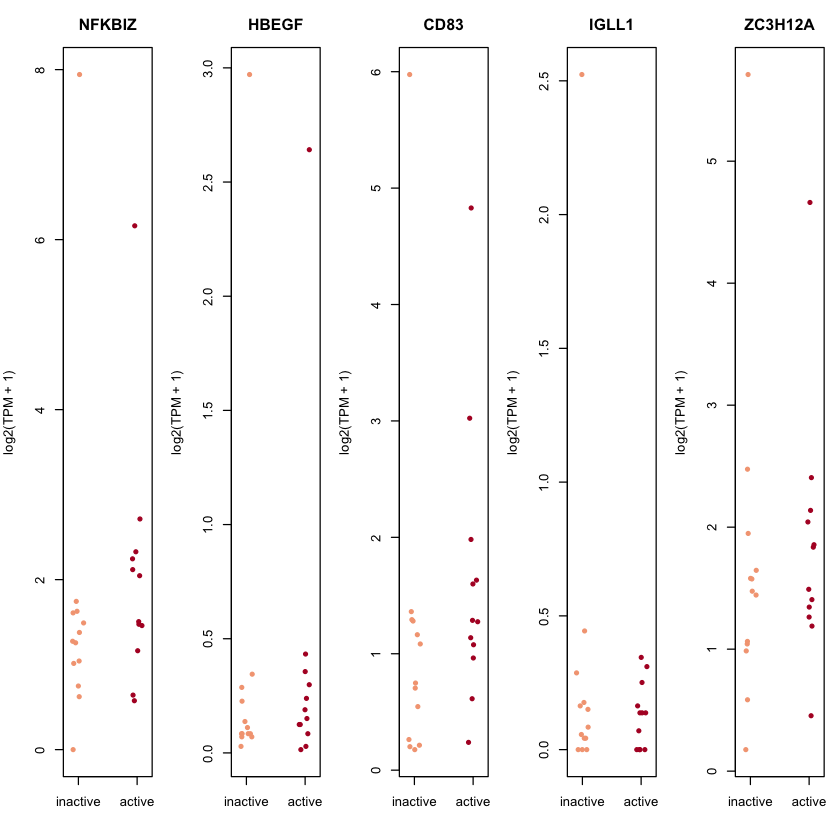

In [10]:
figure <- function() {
  par(mfrow = c(1, 5), mar = c(4, 4, 3, 1))
  for (g in top5) {
    y <- log2(tpm[g, ] + 1)
    stripchart(list(inactive = y[!act], active = y[act]), vertical = TRUE, method = "jitter", pch = 19,
               col = c("#F4A582", "#B2182B"), main = g, ylab = "log2(TPM + 1)")
  }
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE232381", "16c_top5_genes_by_sample.png"), width = 14, height = 4, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Result.** For four of the five genes, one inactive sample, GSM7329703, holds 43 to 68% of the TPM summed
over all 25 samples. For IGLL1 another inactive sample, GSM7329701, holds 68%. The ratio of group means is
negative, as in the paper, but the ratio of medians is positive (0.30 to 1.07): the typical active sample
has more, not less. GSM7329703 is one of the 9 samples missing from NCBI's counts.

## Summary: why the paper does not reproduce

- **GEO is not wrong.** The sample labels are consistent, the NCBI counts are the authors' libraries, and
  the authors' own file on GEO gives Table 3's directions.
- **NCBI's counts table leaves out 9 of the 25 samples**, among them the sample that drives the paper's
  largest effects.
- **The paper's largest effects rest on one or two samples.** A fold change of means follows those samples;
  DESeq2 does not, even on all 25 samples with the authors' counts.
- **Sequencing batch is confounded with activity** (p = 0.007).
- **The paper's 9 against 9 cannot be rebuilt**, because GEO does not identify those 18 samples.